In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import optuna
from arch import arch_model

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [24]:
COMMODITIES = {
    'Gold': {
        'ticker':         'GC=F',
        'color':          'gold',
        'extra_tickers':  {},
        'extra_features': [],
    },
    'Silver': {
        'ticker':         'SI=F',
        'color':          'silver',
        'extra_tickers':  {},
        'extra_features': [],
    },
    'Crude Oil': {
        'ticker':         'CL=F',
        'color':          'saddlebrown',
        'extra_tickers':  {'XLE': 'XLE'},
        'extra_features': ['XLE_Return'],
    },
}

SHARED_MACRO = {
    'VIX':   '^VIX',
    'TNX':   '^TNX',
    'SP500': '^GSPC',
    'DXY':   'DX-Y.NYB',
}

BASE_FEATURES = [
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3',
    'RSI14', 'ATR14', 'ATR_Ratio',
    'DXY_Return', 'VIX', 'TNX', 'TNX_Change', 'SP500_Return',
    'RealVol5', 'RealVol21',
    'AbsReturn_Lag1', 'AbsReturn_Lag2',
]

# Crude Oil drops TNX (less relevant) and picks up XLE
CRUDE_OIL_FEATURES = [f for f in BASE_FEATURES if 'TNX' not in f] + ['XLE_Return']

In [8]:
def download_macro():
    print("Downloading shared macro data...")
    macro = {}
    for name, ticker in SHARED_MACRO.items():
        df = yf.download(ticker, start="1970-01-01", progress=False)
        df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
        macro[name] = df
    print("Done.")
    return macro

macro = download_macro()

Done.


In [22]:
def build_features(ticker, macro, extra_tickers, extra_features):
    df = yf.download(ticker, start="1970-01-01", progress=False)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # Reindex all macro series to the commodity's trading calendar
    def align(series):
        return series.reindex(df.index).ffill()

    dxy   = macro['DXY']['Close']
    vix   = macro['VIX']['Close']
    tnx   = macro['TNX']['Close']
    sp500 = macro['SP500']['Close']

    df['DXY_Return']   = np.log(align(dxy) / align(dxy).shift(1))
    df['VIX']          = align(vix)
    df['VIX_Change']   = np.log(align(vix) / align(vix).shift(1))
    df['TNX']          = align(tnx)
    df['TNX_Change']   = align(tnx).diff()
    df['SP500_Return']  = np.log(align(sp500) / align(sp500).shift(1))

    for feat_name, eticker in extra_tickers.items():
        extra = yf.download(eticker, start="1970-01-01", progress=False)
        extra.columns = [col[0] if isinstance(col, tuple) else col for col in extra.columns]
        df[f'{feat_name}_Return'] = np.log(align(extra['Close']) / align(extra['Close']).shift(1))

    df['Log_Return']      = np.log(df['Close'] / df['Close'].shift(1))
    df['Return_Lag1']     = df['Log_Return'].shift(1)
    df['Return_Lag2']     = df['Log_Return'].shift(2)
    df['Return_Lag3']     = df['Log_Return'].shift(3)
    df['RSI14']           = RSIIndicator(close=df['Close'], window=14).rsi()
    df['ATR14']           = AverageTrueRange(
                                high=df['High'], low=df['Low'],
                                close=df['Close'], window=14
                            ).average_true_range()
    df['RealVol5']        = df['Log_Return'].rolling(5).std()
    df['RealVol21']       = df['Log_Return'].rolling(21).std()
    df['ATR_Ratio']       = df['ATR14'] / df['ATR14'].rolling(60).mean()
    df['AbsReturn_Lag1']  = np.abs(df['Log_Return'].shift(1))
    df['AbsReturn_Lag2']  = np.abs(df['Log_Return'].shift(2))
    df['Target_Return']   = df['Log_Return'].shift(-1)
    df['Target_Direction']= np.where(df['Target_Return'] >= 0, 1, 0)
    df['Target_Magnitude']= np.abs(df['Target_Return'])
    print(f"NaN counts:\n{df.isnull().sum()}")
    print(f"Shape before dropna: {df.shape}")
    df.dropna(inplace=True)

    print(f"  {ticker}: {df.shape[0]} rows | {df.index[0].date()} to {df.index[-1].date()}")
    return df

In [10]:
class CommodityLSTM(nn.Module):
    def __init__(self, input_size, h1, h2, dropout):
        super().__init__()
        self.lstm1    = nn.LSTM(input_size, h1, batch_first=True)
        self.drop1    = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(h1, h2, batch_first=True)
        self.drop2    = nn.Dropout(dropout)
        self.fc       = nn.Linear(h2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop1(out)
        out, _ = self.lstm2(out)
        out = self.drop2(out)
        return self.fc(out[:, -1, :])


def train_lstm(model, criterion, X_train, y_train, X_val, y_val,
               lr, batch_size=32, epochs=100, patience=10):
    loader   = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss, best_weights, counter = float('inf'), None, 0

    for _ in range(epochs):
        model.train()
        for Xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(Xb), yb).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    model.load_state_dict(best_weights)
    return model, best_loss


def create_sequences(X, y_raw, y_clf, y_mag, lookback):
    Xs, yr, yc, ym = [], [], [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        yr.append(y_raw[i]); yc.append(y_clf[i]); ym.append(y_mag[i])
    return np.array(Xs), np.array(yr), np.array(yc), np.array(ym)


def to_tensor(arr, dtype=torch.float32):
    return torch.tensor(arr, dtype=dtype).to(DEVICE)

In [11]:
def garch_walk_forward(all_returns, split_idx, n_test):
    print("  Fitting walk-forward GJR-GARCH...")
    forecasts = []
    for i in range(n_test):
        history = all_returns.iloc[:split_idx + i]
        try:
            res = arch_model(history, vol='Garch', p=1, o=1, q=1, dist='normal').fit(
                disp='off', show_warning=False)
            fc    = res.forecast(horizon=1, reindex=False)
            sigma = np.sqrt(fc.variance.values[-1, 0]) / 100
        except Exception:
            sigma = np.abs(history.iloc[-20:]).mean() / 100
        forecasts.append(sigma)
        if i % 200 == 0:
            print(f"    {i}/{n_test}")
    print(f"  Done. Mean vol: {np.mean(forecasts):.6f}")
    return np.array(forecasts)

In [28]:
def tier1_linear(X_train_s, X_test_s, y_train_clf, y_test_clf,
                 y_train_mag, y_test_raw, name):
    print(f"[Tier 1] Linear/Logistic — {name}")
    tscv = TimeSeriesSplit(n_splits=5)
    clf  = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)

    wf_scores = []
    for tr, val in tscv.split(X_train_s):
        clf.fit(X_train_s[tr], y_train_clf.iloc[tr])
        wf_scores.append(accuracy_score(y_train_clf.iloc[val], clf.predict(X_train_s[val])))

    clf.fit(X_train_s, y_train_clf)
    y_pred_dir = clf.predict(X_test_s)
    dir_acc    = accuracy_score(y_test_clf, y_pred_dir) * 100

    reg = LinearRegression()
    reg.fit(X_train_s, y_train_mag)
    y_pred_mag = np.maximum(reg.predict(X_test_s), 0)

    final_preds = np.where(y_pred_dir == 1, 1, -1) * y_pred_mag
    mae  = mean_absolute_error(y_test_raw, final_preds)
    rmse = np.sqrt(mean_squared_error(y_test_raw, final_preds))

    print(f"  Walk-Forward: {np.mean(wf_scores):.2%} +/- {np.std(wf_scores):.2%}")
    print(f"  Direction Accuracy: {dir_acc:.2f}%  |  MAE: {mae:.6f}  |  RMSE: {rmse:.6f}")

    threshold    = np.percentile(np.abs(y_test_raw), 80)
    big_move_idx = np.abs(y_test_raw) > threshold
    big_move_acc = accuracy_score(
    np.sign(y_test_raw.values[big_move_idx]),
    np.sign(final_preds[big_move_idx])
    ) * 100


    return {'dir_acc': dir_acc, 'big_move_acc': big_move_acc, 'mae': mae, 'rmse': rmse, 'preds': final_preds}

In [13]:
def tier2_xgboost(X_train_s, X_test_s, y_train_clf, y_test_clf,
                  y_train_mag, y_test_raw, name):
    print(f"[Tier 2] XGBoost — {name}")
    tscv = TimeSeriesSplit(n_splits=5)

    def obj_clf(trial):
        p = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
            'max_depth':        trial.suggest_int('max_depth', 2, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'random_state': 42, 'tree_method': 'hist',
        }
        scores = []
        for tr, val in tscv.split(X_train_s):
            m = xgb.XGBClassifier(**p)
            m.fit(X_train_s[tr], y_train_clf.iloc[tr], verbose=False)
            scores.append(accuracy_score(y_train_clf.iloc[val], m.predict(X_train_s[val])))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(obj_clf, n_trials=50)
    best_clf_p = {**study.best_params, 'objective': 'binary:logistic',
                  'eval_metric': 'logloss', 'random_state': 42, 'tree_method': 'hist'}

    xgb_clf = xgb.XGBClassifier(**best_clf_p)
    xgb_clf.fit(X_train_s, y_train_clf)
    y_pred_dir = xgb_clf.predict(X_test_s)
    dir_acc    = accuracy_score(y_test_clf, y_pred_dir) * 100

    def obj_reg(trial):
        p = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
            'max_depth':        trial.suggest_int('max_depth', 2, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
            'random_state': 42, 'tree_method': 'hist',
        }
        scores = []
        for tr, val in tscv.split(X_train_s):
            m = xgb.XGBRegressor(**p)
            m.fit(X_train_s[tr], y_train_mag.iloc[tr], verbose=False)
            scores.append(mean_absolute_error(y_train_mag.iloc[val], m.predict(X_train_s[val])))
        return np.mean(scores)

    study_reg = optuna.create_study(direction='minimize')
    study_reg.optimize(obj_reg, n_trials=30)
    best_reg_p = {**study_reg.best_params, 'random_state': 42, 'tree_method': 'hist'}

    xgb_reg = xgb.XGBRegressor(**best_reg_p)
    xgb_reg.fit(X_train_s, y_train_mag)
    y_pred_mag  = np.maximum(xgb_reg.predict(X_test_s), 0)
    final_preds = np.where(y_pred_dir == 1, 1, -1) * y_pred_mag
    mae  = mean_absolute_error(y_test_raw, final_preds)
    rmse = np.sqrt(mean_squared_error(y_test_raw, final_preds))

    threshold    = np.percentile(np.abs(y_test_raw), 80)
    big_move_idx = np.abs(y_test_raw) > threshold
    big_move_acc = accuracy_score(
        np.sign(y_test_raw.values[big_move_idx]),
        np.sign(final_preds[big_move_idx])
    ) * 100

    print(f"  Direction Accuracy: {dir_acc:.2f}%  |  Big Move: {big_move_acc:.2f}%  |  MAE: {mae:.6f}  |  RMSE: {rmse:.6f}")
    return {'dir_acc': dir_acc, 'big_move_acc': big_move_acc, 'mae': mae,
            'rmse': rmse, 'preds': final_preds, 'clf': xgb_clf}

In [14]:
def tier3_lstm(X_train_raw, X_test_raw, y_train_raw, y_test_raw,
               y_train_clf, y_test_clf, y_train_mag, scaler, features, name):
    print(f"[Tier 3] LSTM — {name}")

    X_train_s = scaler.transform(X_train_raw)
    X_test_s  = scaler.transform(X_test_raw)
    y_tr_clf  = np.where(y_train_raw >= 0, 1.0, 0.0)
    y_te_clf  = np.where(y_test_raw >= 0, 1.0, 0.0)
    y_tr_mag  = np.abs(y_train_raw)

    def obj_clf(trial):
        h1, h2   = trial.suggest_int('h1', 32, 128, step=32), trial.suggest_int('h2', 16, 64, step=16)
        dropout  = trial.suggest_float('dropout', 0.1, 0.5)
        lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        lookback = trial.suggest_int('lookback', 5, 30, step=5)
        Xs, _, yc, _ = create_sequences(X_train_s, y_train_raw, y_tr_clf, y_tr_mag, lookback)
        vs = int(len(Xs) * 0.8)
        _, vl = train_lstm(
            CommodityLSTM(len(features), h1, h2, dropout).to(DEVICE),
            nn.BCEWithLogitsLoss(),
            to_tensor(Xs[:vs]), to_tensor(yc[:vs]).unsqueeze(1),
            to_tensor(Xs[vs:]), to_tensor(yc[vs:]).unsqueeze(1),
            lr=lr, epochs=30, patience=5)
        return vl

    study = optuna.create_study(direction='minimize')
    study.optimize(obj_clf, n_trials=30)
    best_c   = study.best_params
    lookback = best_c['lookback']
    print(f"  Best lookback: {lookback} days")

    Xtr_seq, ytr_raw, ytr_clf, ytr_mag = create_sequences(X_train_s, y_train_raw, y_tr_clf, y_tr_mag, lookback)
    Xte_seq, yte_raw, yte_clf, yte_mag = create_sequences(X_test_s,  y_test_raw,  y_te_clf, np.abs(y_test_raw), lookback)
    vs = int(len(Xtr_seq) * 0.8)

    Xtr_t  = to_tensor(Xtr_seq); Xval_t = to_tensor(Xtr_seq[vs:]); Xte_t = to_tensor(Xte_seq)
    ytr_c  = to_tensor(ytr_clf).unsqueeze(1);  yval_c = to_tensor(ytr_clf[vs:]).unsqueeze(1)
    ytr_m  = to_tensor(ytr_mag).unsqueeze(1);  yval_m = to_tensor(ytr_mag[vs:]).unsqueeze(1)

    clf_model = CommodityLSTM(len(features), best_c['h1'], best_c['h2'], best_c['dropout']).to(DEVICE)
    clf_model, _ = train_lstm(clf_model, nn.BCEWithLogitsLoss(), Xtr_t, ytr_c, Xval_t, yval_c,
                               lr=best_c['lr'], epochs=100, patience=10)
    clf_model.eval()
    with torch.no_grad():
        y_pred_dir = np.where(torch.sigmoid(clf_model(Xte_t)).cpu().numpy().flatten() > 0.5, 1, 0)
    dir_acc = accuracy_score(yte_clf, y_pred_dir) * 100

    def obj_mag(trial):
        h1, h2  = trial.suggest_int('h1', 32, 128, step=32), trial.suggest_int('h2', 16, 64, step=16)
        dropout = trial.suggest_float('dropout', 0.1, 0.5)
        lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        _, vl = train_lstm(
            CommodityLSTM(len(features), h1, h2, dropout).to(DEVICE),
            nn.MSELoss(), Xtr_t[:vs], ytr_m[:vs], Xval_t, yval_m,
            lr=lr, epochs=30, patience=5)
        return vl

    study_mag = optuna.create_study(direction='minimize')
    study_mag.optimize(obj_mag, n_trials=30)
    best_m = study_mag.best_params

    mag_model = CommodityLSTM(len(features), best_m['h1'], best_m['h2'], best_m['dropout']).to(DEVICE)
    mag_model, _ = train_lstm(mag_model, nn.MSELoss(), Xtr_t, ytr_m, Xval_t, yval_m,
                               lr=best_m['lr'], epochs=100, patience=10)
    mag_model.eval()
    with torch.no_grad():
        y_pred_mag = np.maximum(mag_model(Xte_t).cpu().numpy().flatten(), 0)

    final_preds = np.where(y_pred_dir == 1, 1, -1) * y_pred_mag
    mae  = mean_absolute_error(yte_raw, final_preds)
    rmse = np.sqrt(mean_squared_error(yte_raw, final_preds))

    threshold    = np.percentile(np.abs(yte_raw), 80)
    big_move_acc = accuracy_score(
        np.sign(yte_raw[np.abs(yte_raw) > threshold]),
        np.sign(final_preds[np.abs(yte_raw) > threshold])
    ) * 100

    print(f"  Direction Accuracy: {dir_acc:.2f}%  |  Big Move: {big_move_acc:.2f}%  |  MAE: {mae:.6f}  |  RMSE: {rmse:.6f}")
    return {'dir_acc': dir_acc, 'big_move_acc': big_move_acc, 'mae': mae, 'rmse': rmse,
            'preds': final_preds, 'clf_model': clf_model, 'lookback': lookback,
            'yte_raw': yte_raw, 'yte_clf': yte_clf}

In [15]:
def tier4_lstm_garch(X_train_raw, X_test_raw, y_train_raw, y_test_raw,
                     scaler, features, garch_forecasts, clf_model, lookback, name):
    print(f"[Tier 4] LSTM + GARCH — {name}")

    X_train_s = scaler.transform(X_train_raw)
    X_test_s  = scaler.transform(X_test_raw)
    y_tr_clf  = np.where(y_train_raw >= 0, 1.0, 0.0)
    y_te_clf  = np.where(y_test_raw >= 0, 1.0, 0.0)

    _, _, _, _ = create_sequences(X_train_s, y_train_raw, y_tr_clf, np.abs(y_train_raw), lookback)
    Xte_seq, yte_raw, yte_clf, _ = create_sequences(
        X_test_s, y_test_raw, y_te_clf, np.abs(y_test_raw), lookback)

    clf_model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(clf_model(to_tensor(Xte_seq))).cpu().numpy().flatten()
    y_pred_dir   = np.where(probs > 0.5, 1, -1)
    garch_seq    = garch_forecasts[lookback:]
    final_preds  = y_pred_dir * garch_seq
    mae  = mean_absolute_error(yte_raw, final_preds)
    rmse = np.sqrt(mean_squared_error(yte_raw, final_preds))
    dir_acc = accuracy_score(yte_clf, np.where(y_pred_dir == 1, 1, 0)) * 100

    threshold    = np.percentile(np.abs(yte_raw), 80)
    big_move_acc = accuracy_score(
        np.sign(yte_raw[np.abs(yte_raw) > threshold]),
        np.sign(final_preds[np.abs(yte_raw) > threshold])
    ) * 100

    print(f"  Direction Accuracy: {dir_acc:.2f}%  |  Big Move: {big_move_acc:.2f}%  |  MAE: {mae:.6f}  |  RMSE: {rmse:.6f}")
    return {'dir_acc': dir_acc, 'big_move_acc': big_move_acc, 'mae': mae,
            'rmse': rmse, 'preds': final_preds, 'yte_raw': yte_raw, 'yte_clf': yte_clf}

In [16]:
def tier5_xgboost_garch(X_train_s, X_test_s, y_train_clf, y_test_clf,
                        y_test_raw, garch_forecasts, name):
    print(f"[Tier 5] XGBoost + GARCH — {name}")
    tscv = TimeSeriesSplit(n_splits=5)

    def obj_clf(trial):
        p = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
            'max_depth':        trial.suggest_int('max_depth', 2, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'random_state': 42, 'tree_method': 'hist',
        }
        scores = []
        for tr, val in tscv.split(X_train_s):
            m = xgb.XGBClassifier(**p)
            m.fit(X_train_s[tr], y_train_clf.iloc[tr], verbose=False)
            scores.append(accuracy_score(y_train_clf.iloc[val], m.predict(X_train_s[val])))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(obj_clf, n_trials=50)
    best_p = {**study.best_params, 'objective': 'binary:logistic', 'eval_metric': 'logloss',
              'random_state': 42, 'tree_method': 'hist'}

    xgb_clf = xgb.XGBClassifier(**best_p)
    xgb_clf.fit(X_train_s, y_train_clf)
    y_pred_dir   = xgb_clf.predict(X_test_s)
    dir_acc      = accuracy_score(y_test_clf, y_pred_dir) * 100
    final_preds  = np.where(y_pred_dir == 1, 1, -1) * garch_forecasts
    mae  = mean_absolute_error(y_test_raw, final_preds)
    rmse = np.sqrt(mean_squared_error(y_test_raw, final_preds))

    threshold    = np.percentile(np.abs(y_test_raw), 80)
    big_move_idx = np.abs(y_test_raw) > threshold
    big_move_acc = accuracy_score(
        np.sign(y_test_raw.values[big_move_idx]),
        np.sign(final_preds[big_move_idx])
    ) * 100

    print(f"  Direction Accuracy: {dir_acc:.2f}%  |  Big Move: {big_move_acc:.2f}%  |  MAE: {mae:.6f}  |  RMSE: {rmse:.6f}")
    return {'dir_acc': dir_acc, 'big_move_acc': big_move_acc, 'mae': mae,
            'rmse': rmse, 'preds': final_preds, 'clf': xgb_clf}

In [17]:
def plot_results(results, y_test_raw, commodity_name, color):
    tier_labels = {
        'tier1': 'Tier 1: Linear/Logistic',
        'tier2': 'Tier 2: XGBoost',
        'tier3': 'Tier 3: LSTM',
        'tier4': 'Tier 4: LSTM + GARCH',
        'tier5': 'Tier 5: XGBoost + GARCH',
    }

    fig, axes = plt.subplots(5, 1, figsize=(16, 22))
    fig.suptitle(f'{commodity_name} — Actual vs Predicted Log Returns',
                 fontsize=15, fontweight='bold', y=1.005)

    actual = y_test_raw.values if hasattr(y_test_raw, 'values') else y_test_raw
    idx    = y_test_raw.index  if hasattr(y_test_raw, 'index')  else range(len(actual))

    for ax, (tier_key, label) in zip(axes, tier_labels.items()):
        if tier_key not in results:
            continue
        preds   = results[tier_key]['preds']
        act_use = actual[-len(preds):]
        idx_use = idx[-len(preds):]

        ax.plot(idx_use, act_use, color=color,      linewidth=1.0, alpha=0.7, label='Actual')
        ax.plot(idx_use, preds,   color='steelblue', linewidth=1.0, linestyle='--', alpha=0.9, label='Predicted')
        ax.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
        ax.set_title(label, fontsize=11)
        ax.set_ylabel('Log Return')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'{commodity_name.replace(" ", "_")}_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()

In [18]:
def next_day_prediction(df, X, scaler, xgb_clf, garch_forecasts, commodity_name):
    last_row_s = scaler.transform(X.iloc[[-1]])
    prob_up    = xgb_clf.predict_proba(last_row_s)[0][1]
    pred_dir   = 1 if prob_up > 0.5 else -1
    pred_mag   = garch_forecasts[-1]
    combined   = pred_dir * pred_mag
    last_price = float(df['Close'].iloc[-1])
    next_price = last_price * np.exp(combined)

    print(f"Next Day Prediction — {commodity_name} (XGBoost + GARCH)")
    print(f"  Last Price        : ${last_price:,.2f}")
    print(f"  Probability Up    : {prob_up:.2%}")
    print(f"  GARCH Vol Forecast: {pred_mag:.6f}")
    print(f"  Predicted Return  : {combined:.6f}")
    print(f"  Predicted Price   : ${next_price:,.2f}")
    print(f"  Expected Move ($) : ${next_price - last_price:,.2f}")
    print(f"  Direction         : {'UP' if pred_dir == 1 else 'DOWN'}")

In [19]:
def run_commodity(name, config, macro):
    print(f"\n{'#'*55}")
    print(f"  {name} ({config['ticker']})")
    print(f"{'#'*55}")

    df       = build_features(config['ticker'], macro, config['extra_tickers'], config['extra_features'])
    features = list(dict.fromkeys(
        CRUDE_OIL_FEATURES + config['extra_features'] if name == 'Crude Oil' else BASE_FEATURES
    ))

    X   = df[features]
    y_raw = df['Target_Return']
    y_clf = df['Target_Direction']
    y_mag = df['Target_Magnitude']

    split_idx   = int(len(X) * 0.80)
    X_train_raw = X.iloc[:split_idx];  X_test_raw = X.iloc[split_idx:]
    y_train_clf = y_clf.iloc[:split_idx]; y_test_clf = y_clf.iloc[split_idx:]
    y_train_mag = y_mag.iloc[:split_idx]; y_test_mag = y_mag.iloc[split_idx:]
    y_train_raw = y_raw.iloc[:split_idx].values
    y_test_raw  = y_raw.iloc[split_idx:]

    print(f"  Train: {X_train_raw.index[0].date()} to {X_train_raw.index[-1].date()} ({len(X_train_raw)} rows)")
    print(f"  Test : {X_test_raw.index[0].date()} to {X_test_raw.index[-1].date()} ({len(X_test_raw)} rows)")

    scaler    = RobustScaler()
    X_train_s = scaler.fit_transform(X_train_raw)
    X_test_s  = scaler.transform(X_test_raw)

    garch_forecasts = garch_walk_forward(df['Log_Return'] * 100, split_idx, len(y_test_raw))

    results = {}
    results['tier1'] = tier1_linear(X_train_s, X_test_s, y_train_clf, y_test_clf,
                                     y_train_mag, y_test_raw, name)
    results['tier2'] = tier2_xgboost(X_train_s, X_test_s, y_train_clf, y_test_clf,
                                      y_train_mag, y_test_raw, name)
    results['tier3'] = tier3_lstm(X_train_raw, X_test_raw, y_train_raw, y_test_raw.values,
                                   y_train_clf, y_test_clf, y_train_mag.values,
                                   scaler, features, name)
    results['tier4'] = tier4_lstm_garch(X_train_raw, X_test_raw, y_train_raw, y_test_raw.values,
                                         scaler, features, garch_forecasts,
                                         results['tier3']['clf_model'],
                                         results['tier3']['lookback'], name)
    results['tier5'] = tier5_xgboost_garch(X_train_s, X_test_s, y_train_clf, y_test_clf,
                                            y_test_raw, garch_forecasts, name)

    plot_results(results, y_test_raw, name, config['color'])
    next_day_prediction(df, X, scaler, results['tier5']['clf'], garch_forecasts, name)

    return results

In [20]:
def print_summary(all_results):
    tier_names = {
        'tier1': 'Linear/Logistic',
        'tier2': 'XGBoost',
        'tier3': 'LSTM',
        'tier4': 'LSTM + GARCH',
        'tier5': 'XGBoost + GARCH',
    }
    rows = []
    for commodity, results in all_results.items():
        for tier_key, label in tier_names.items():
            if tier_key not in results:
                continue
            r = results[tier_key]
            rows.append({
                'Commodity':    commodity,
                'Model':        label,
                'Dir Acc (%)':  f"{r['dir_acc']:.2f}",
                'Big Move (%)': f"{r['big_move_acc']:.2f}" if r['big_move_acc'] else '-',
                'MAE':          f"{r['mae']:.6f}",
                'RMSE':         f"{r['rmse']:.6f}",
            })

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))

    print("\nBest model per commodity (by MAE):")
    for commodity, results in all_results.items():
        best = min(results, key=lambda t: results[t]['mae'])
        r    = results[best]
        print(f"  {commodity:12s}  {tier_names[best]:20s}  Dir Acc: {r['dir_acc']:.2f}%  MAE: {r['mae']:.6f}")


#######################################################
  Gold (GC=F)
#######################################################
NaN counts:
Close                0
High                 0
Low                  0
Open                 0
Volume               0
DXY_Return           1
VIX                  0
VIX_Change           1
TNX                  0
TNX_Change           1
SP500_Return         1
Log_Return           1
Return_Lag1          2
Return_Lag2          3
Return_Lag3          4
RSI14               13
ATR14                0
RealVol5             5
RealVol21           21
ATR_Ratio           59
AbsReturn_Lag1       2
AbsReturn_Lag2       3
Target_Return        1
Target_Direction     0
Target_Magnitude     1
dtype: int64
Shape before dropna: (6444, 25)
  GC=F: 6384 rows | 2000-11-22 to 2026-05-05
  Train: 2000-11-22 to 2021-04-07 (5107 rows)
  Test : 2021-04-08 to 2026-05-05 (1277 rows)
  Fitting walk-forward GJR-GARCH...
    0/1277
    200/1277
    400/1277
    600/1277
    800/1277
    1

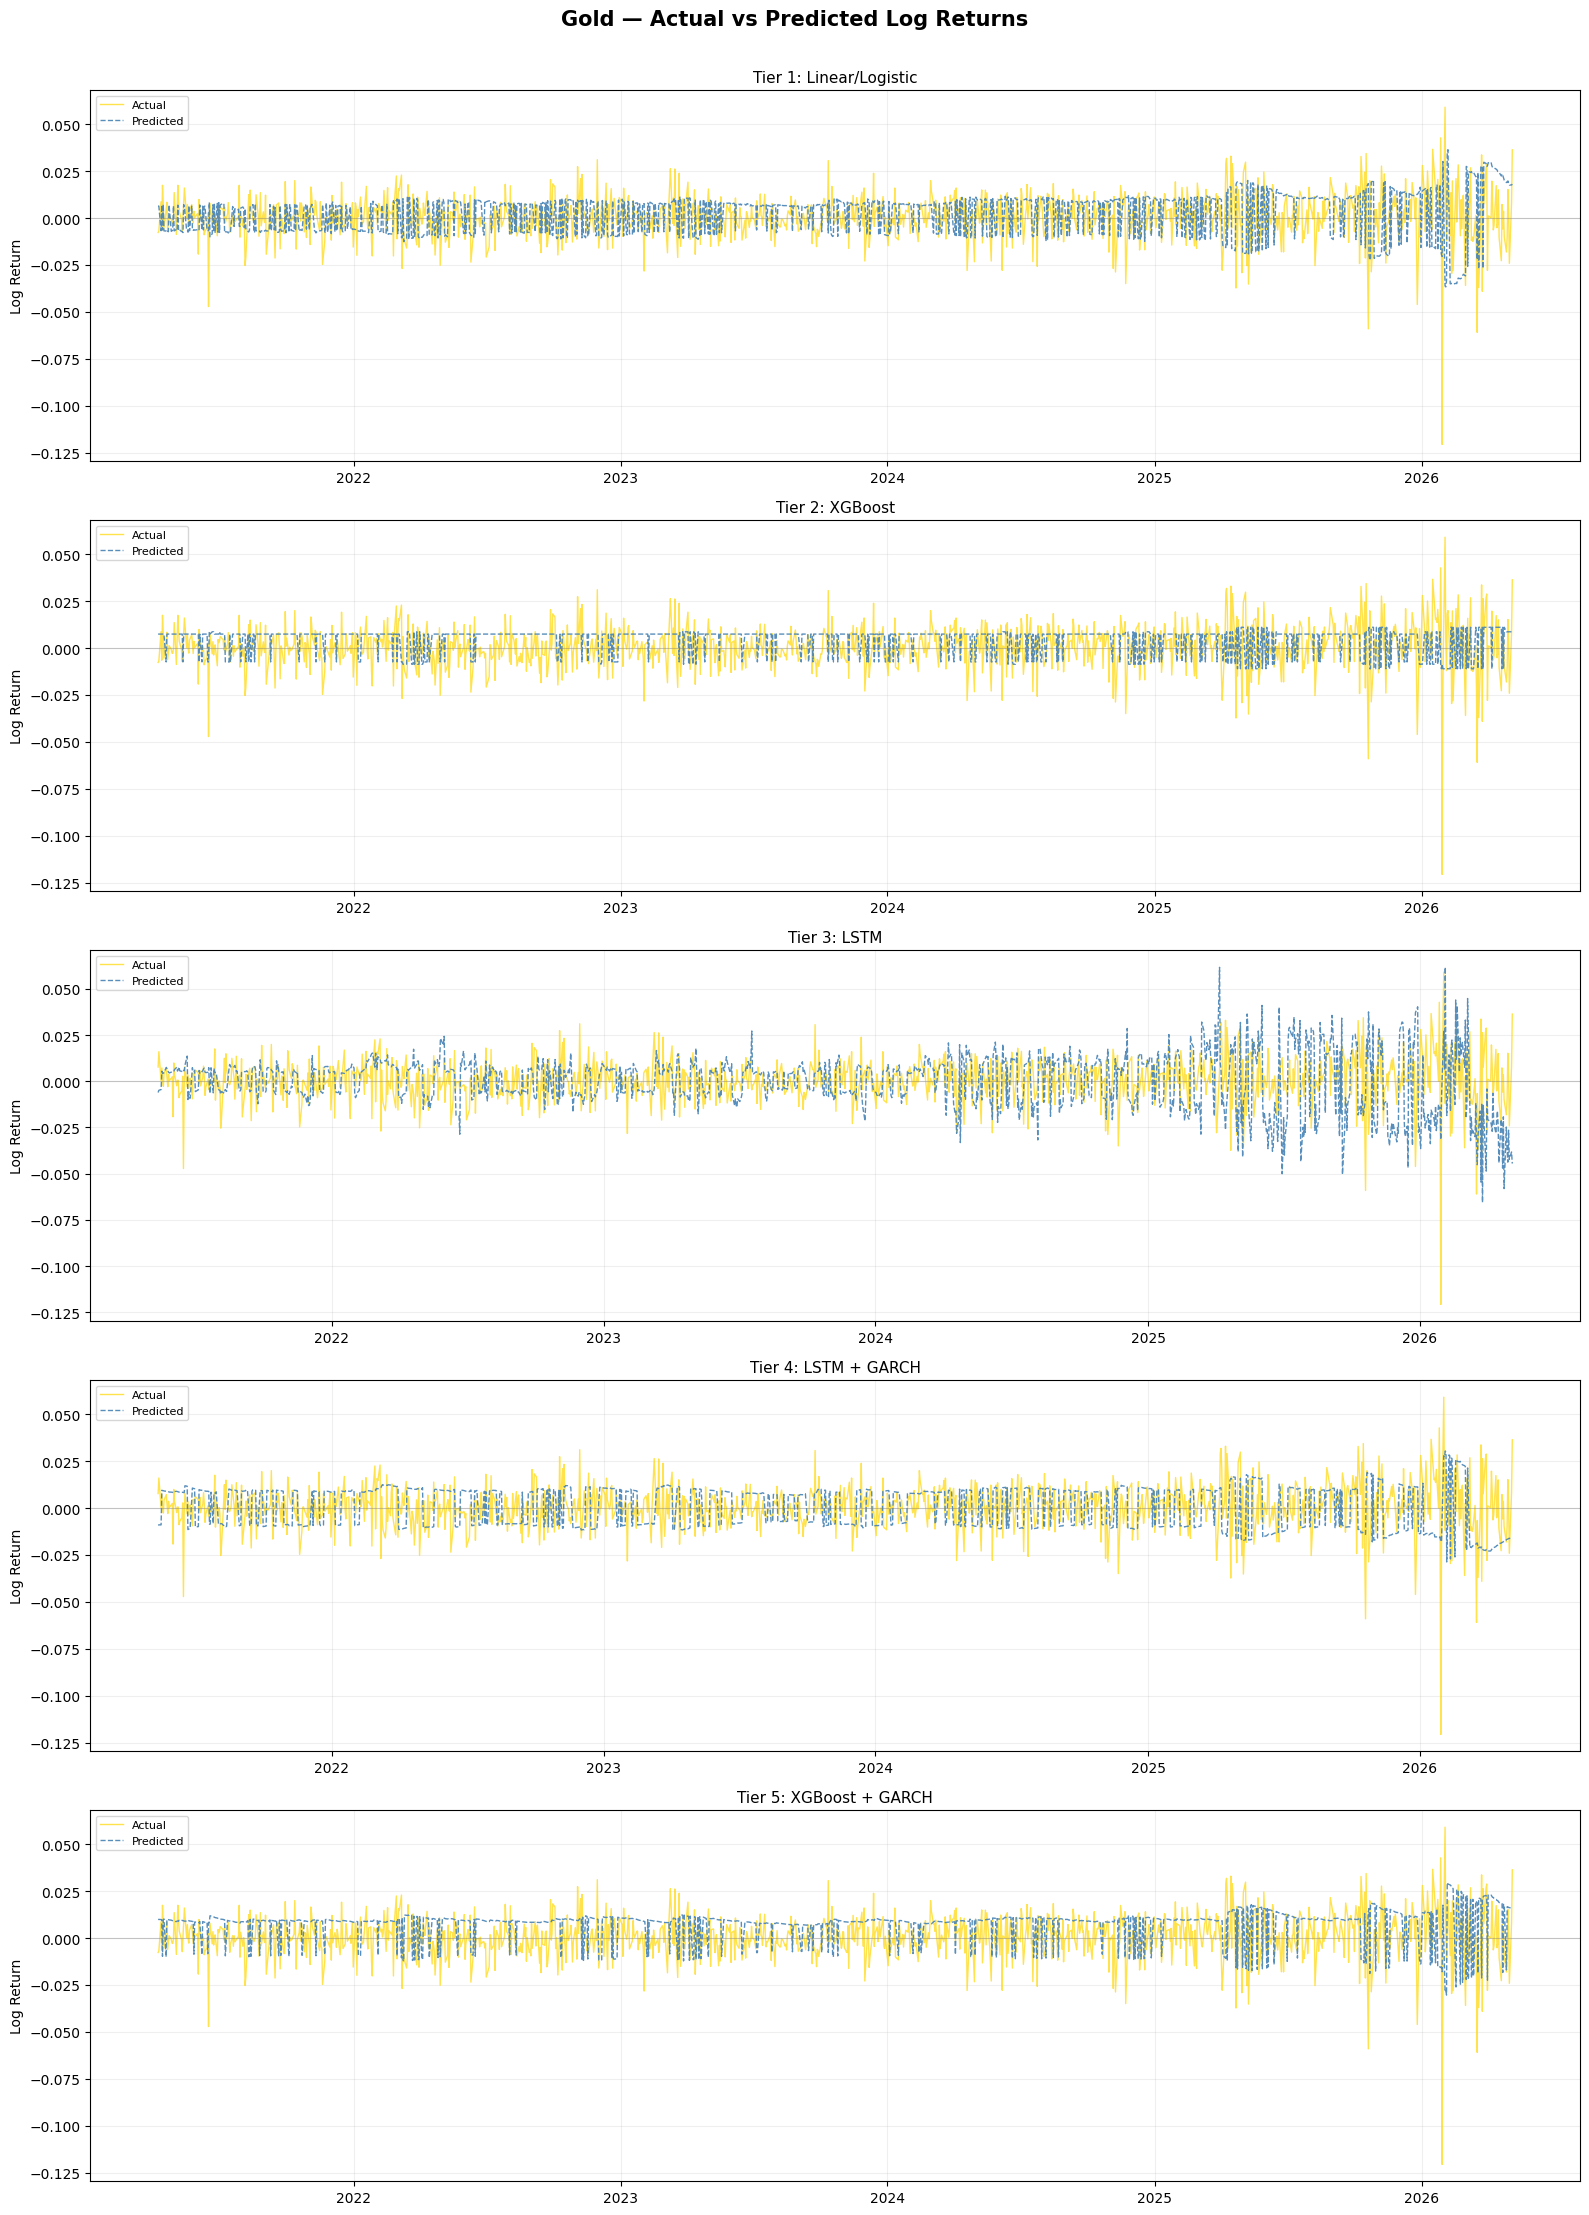

Next Day Prediction — Gold (XGBoost + GARCH)
  Last Price        : $4,555.80
  Probability Up    : 54.72%
  GARCH Vol Forecast: 0.016024
  Predicted Return  : 0.016024
  Predicted Price   : $4,629.39
  Expected Move ($) : $73.59
  Direction         : UP

#######################################################
  Silver (SI=F)
#######################################################
NaN counts:
Close                0
High                 0
Low                  0
Open                 0
Volume               0
DXY_Return           1
VIX                  0
VIX_Change           1
TNX                  0
TNX_Change           1
SP500_Return         1
Log_Return           1
Return_Lag1          2
Return_Lag2          3
Return_Lag3          4
RSI14               13
ATR14                0
RealVol5             5
RealVol21           21
ATR_Ratio           59
AbsReturn_Lag1       2
AbsReturn_Lag2       3
Target_Return        1
Target_Direction     0
Target_Magnitude     1
dtype: int64
Shape before drop

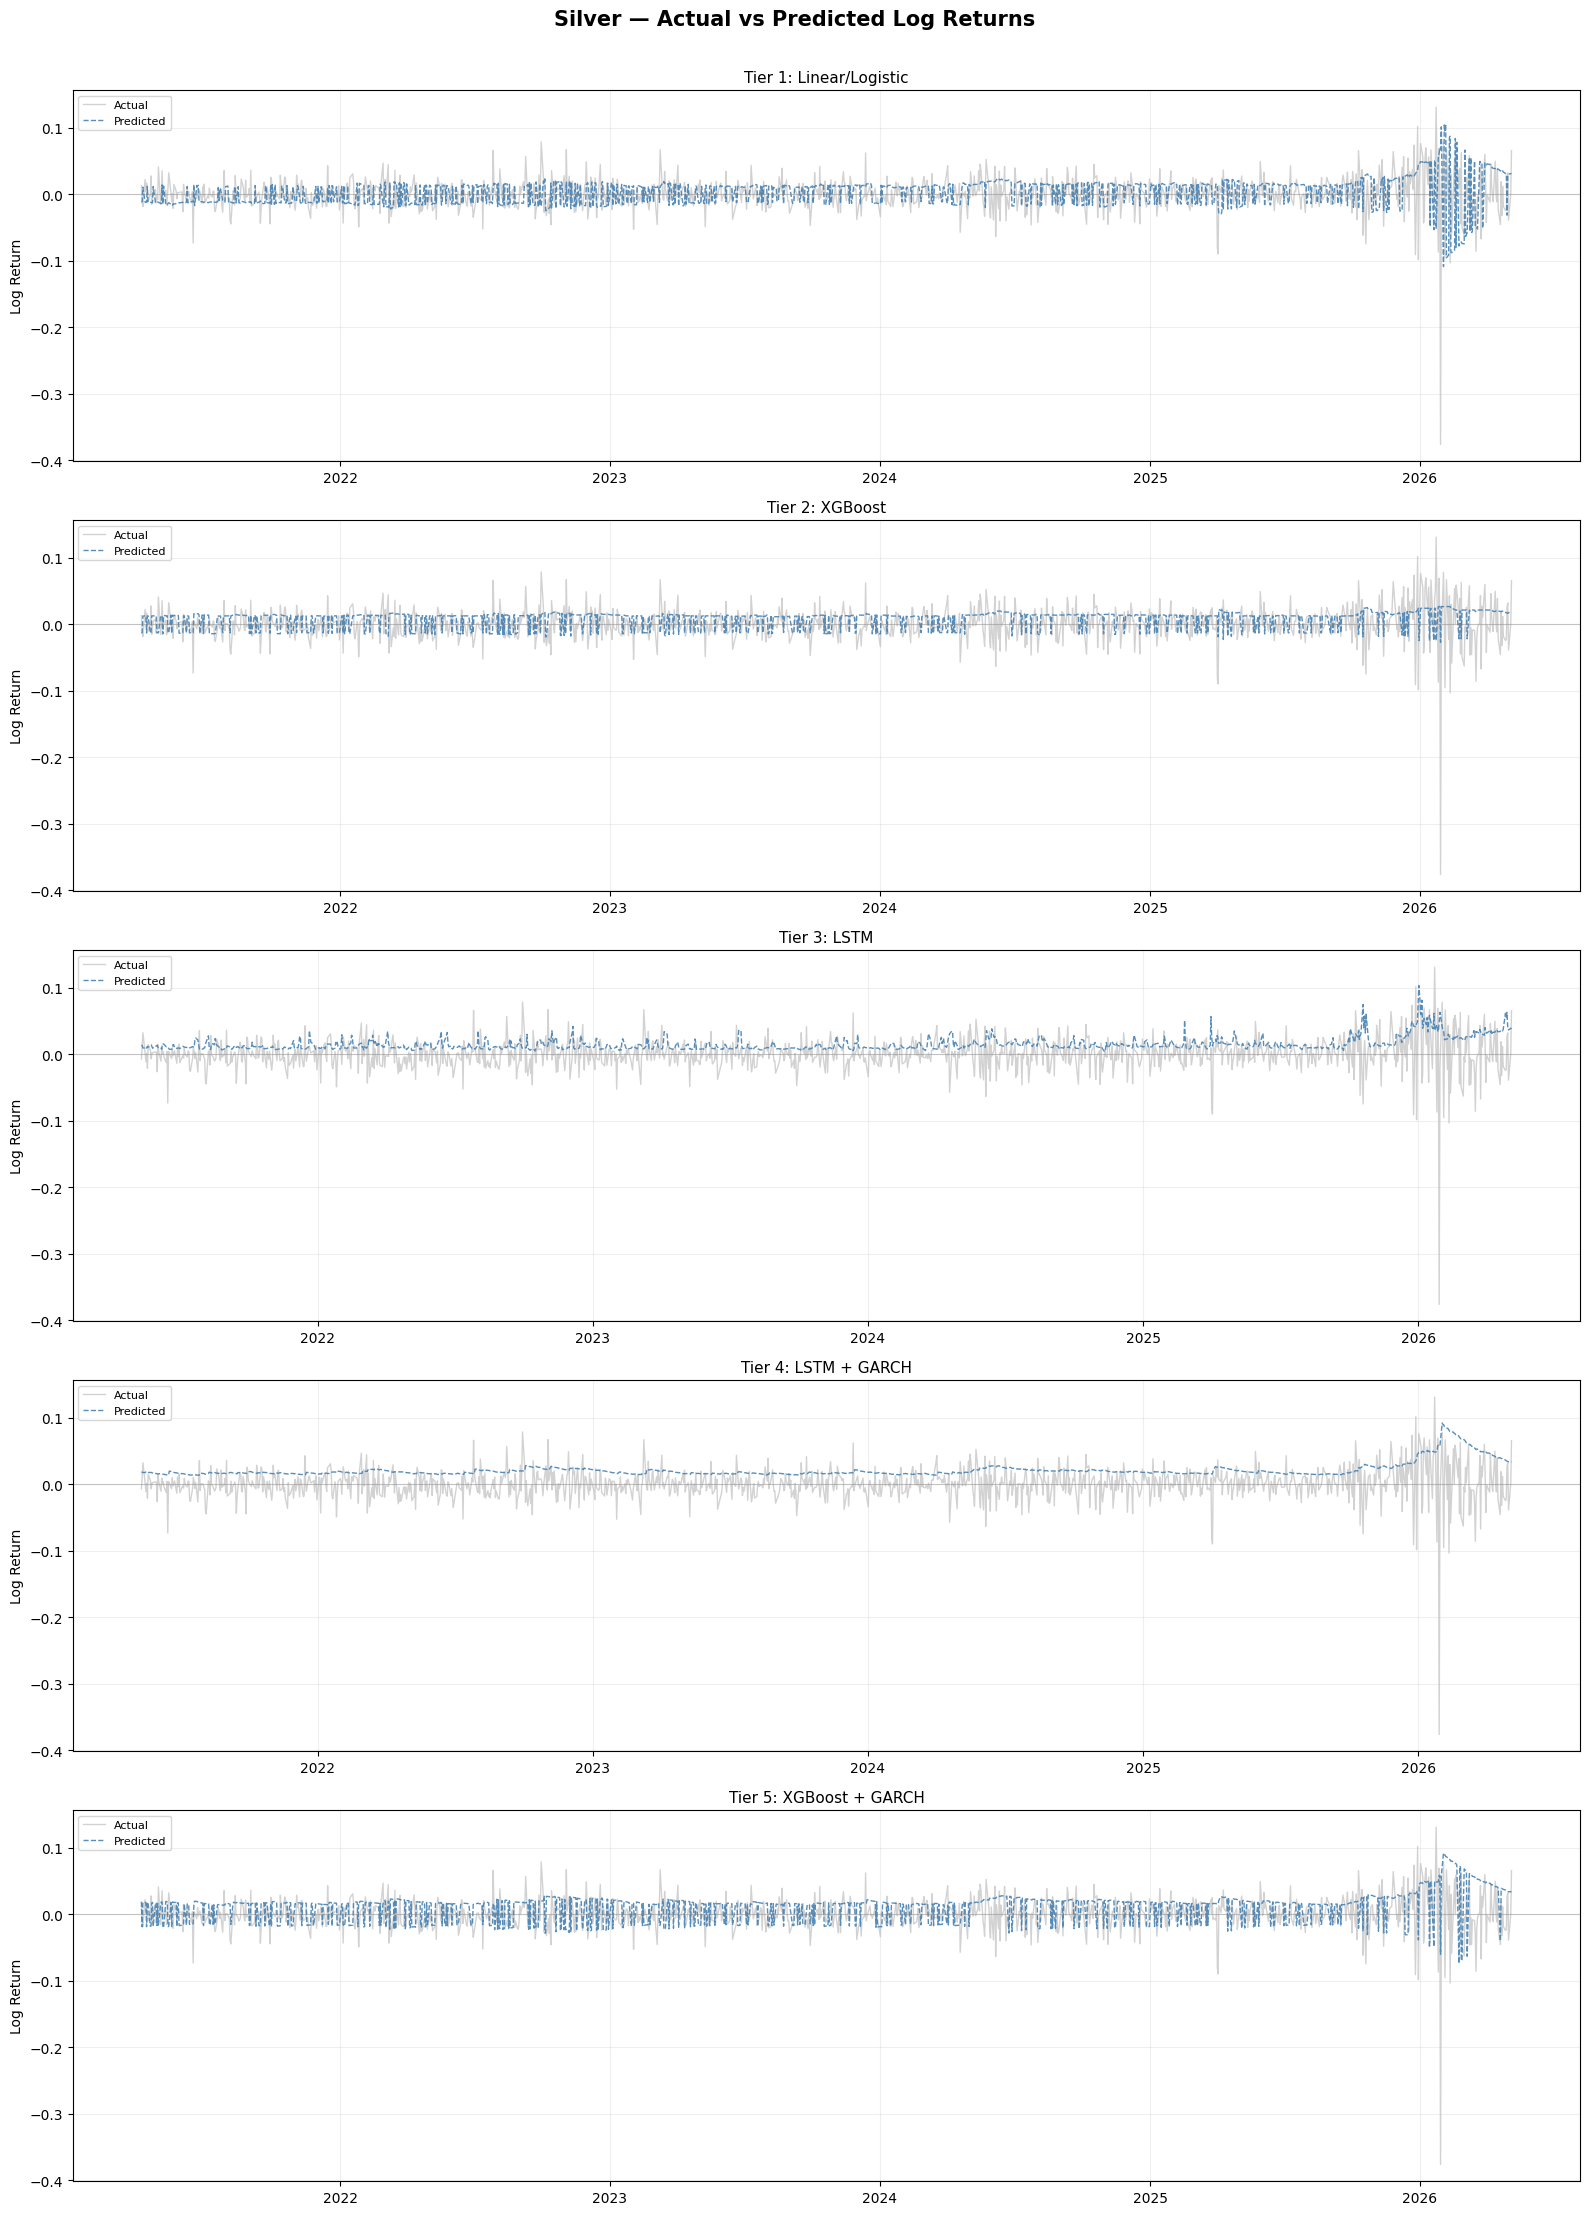

Next Day Prediction — Silver (XGBoost + GARCH)
  Last Price        : $73.11
  Probability Up    : 61.58%
  GARCH Vol Forecast: 0.034159
  Predicted Return  : 0.034159
  Predicted Price   : $75.65
  Expected Move ($) : $2.54
  Direction         : UP

#######################################################
  Crude Oil (CL=F)
#######################################################
NaN counts:
Close                0
High                 0
Low                  0
Open                 0
Volume               0
DXY_Return           1
VIX                  0
VIX_Change           1
TNX                  0
TNX_Change           1
SP500_Return         1
XLE_Return           1
Log_Return           3
Return_Lag1          4
Return_Lag2          5
Return_Lag3          6
RSI14               13
ATR14                0
RealVol5            11
RealVol21           43
ATR_Ratio           59
AbsReturn_Lag1       4
AbsReturn_Lag2       5
Target_Return        3
Target_Direction     0
Target_Magnitude     3
dtype: in

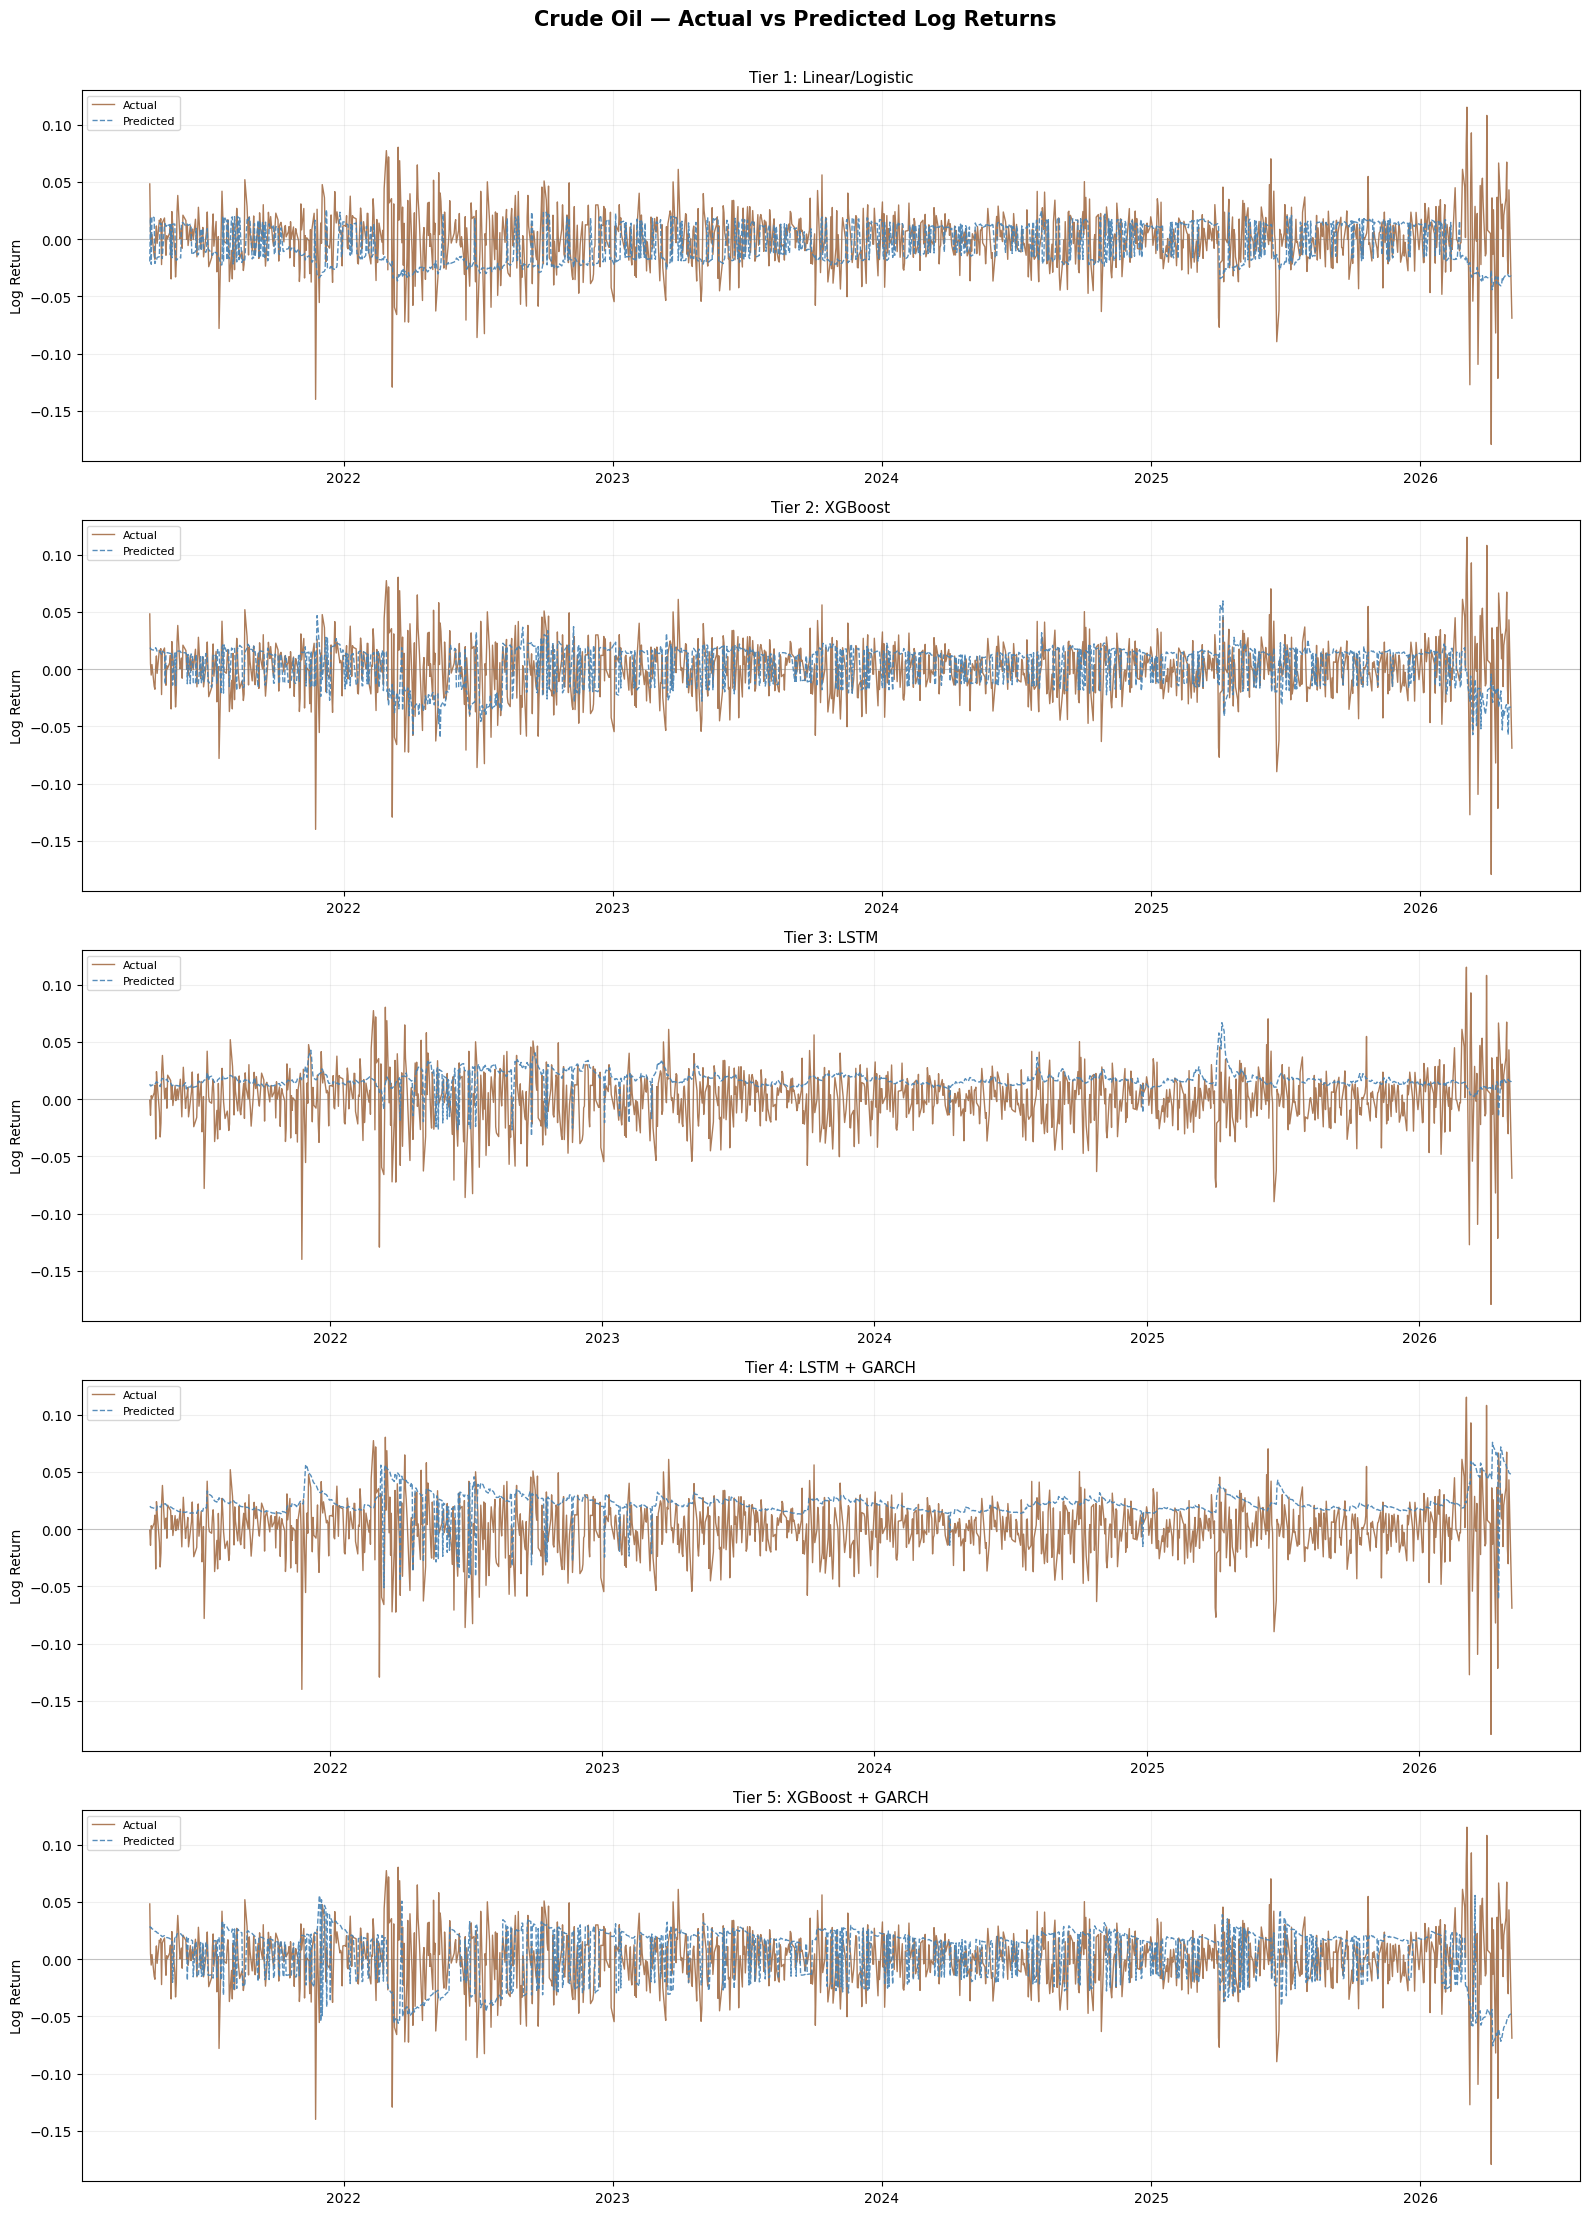

Next Day Prediction — Crude Oil (XGBoost + GARCH)
  Last Price        : $102.27
  Probability Up    : 34.44%
  GARCH Vol Forecast: 0.046348
  Predicted Return  : -0.046348
  Predicted Price   : $97.64
  Expected Move ($) : $-4.63
  Direction         : DOWN
Commodity           Model Dir Acc (%) Big Move (%)      MAE     RMSE
     Gold Linear/Logistic       51.37            - 0.012055 0.016122
     Gold         XGBoost       53.95        52.73 0.010274 0.013814
     Gold            LSTM       50.96        49.00 0.014020 0.019023
     Gold    LSTM + GARCH       50.96        49.00 0.012465 0.015942
     Gold XGBoost + GARCH       54.03        52.34 0.011930 0.015671
   Silver Linear/Logistic       52.19            - 0.021592 0.032526
   Silver         XGBoost       53.76        57.42 0.019603 0.027506
   Silver            LSTM       52.99        55.38 0.020601 0.030166
   Silver    LSTM + GARCH       52.99        55.38 0.024247 0.033863
   Silver XGBoost + GARCH       53.21        57.81 0.

In [25]:
all_results = {}

for name, config in COMMODITIES.items():
    all_results[name] = run_commodity(name, config, macro)

print_summary(all_results)

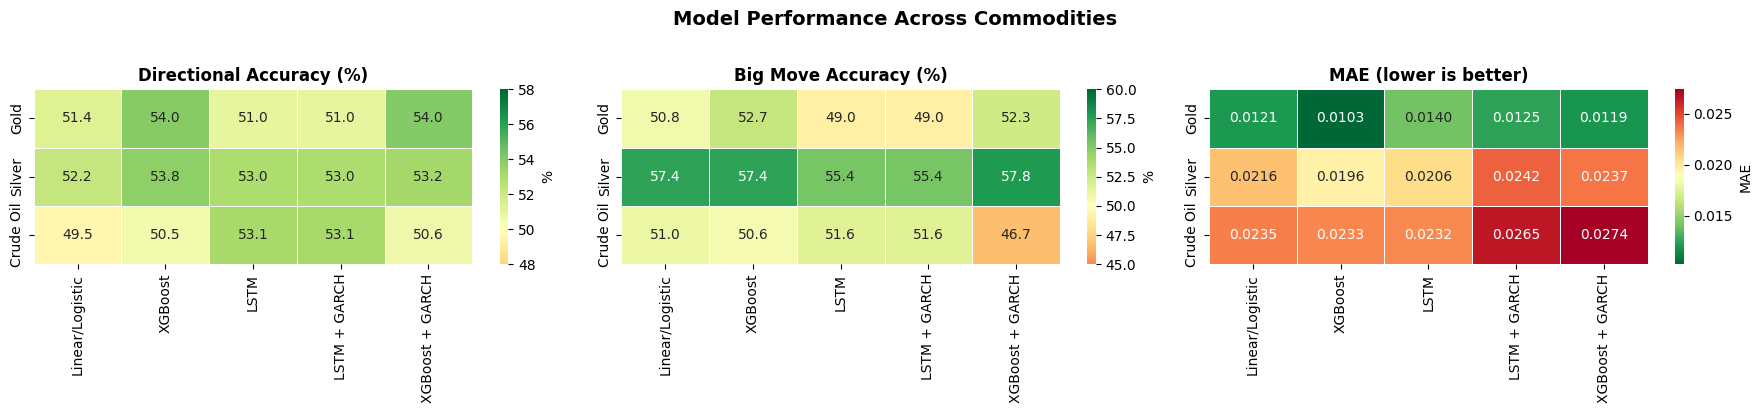

In [30]:
import seaborn as sns

tier_names = {
    'tier1': 'Linear/Logistic',
    'tier2': 'XGBoost',
    'tier3': 'LSTM',
    'tier4': 'LSTM + GARCH',
    'tier5': 'XGBoost + GARCH',
}

commodities = list(all_results.keys())
models      = list(tier_names.values())

# Build matrices
dir_acc_matrix  = pd.DataFrame(index=commodities, columns=models, dtype=float)
big_move_matrix = pd.DataFrame(index=commodities, columns=models, dtype=float)
mae_matrix      = pd.DataFrame(index=commodities, columns=models, dtype=float)

for commodity, results in all_results.items():
    for tier_key, label in tier_names.items():
        if tier_key not in results:
            continue
        r = results[tier_key]
        dir_acc_matrix.loc[commodity, label]  = r['dir_acc']
        big_move_matrix.loc[commodity, label] = r['big_move_acc'] if r['big_move_acc'] else np.nan
        mae_matrix.loc[commodity, label]      = r['mae']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

row_order = ['Gold', 'Silver', 'Crude Oil']

sns.heatmap(dir_acc_matrix.loc[row_order].astype(float), ax=axes[0], annot=True, fmt='.1f',
            cmap='RdYlGn', center=50, vmin=48, vmax=58,
            linewidths=0.5, cbar_kws={'label': '%'})
axes[0].set_title('Directional Accuracy (%)', fontweight='bold')

sns.heatmap(big_move_matrix.loc[row_order].astype(float), ax=axes[1], annot=True, fmt='.1f',
            cmap='RdYlGn', center=50, vmin=45, vmax=60,
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('Big Move Accuracy (%)', fontweight='bold')

sns.heatmap(mae_matrix.loc[row_order].astype(float), ax=axes[2], annot=True, fmt='.4f',
            cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'MAE'})
axes[2].set_title('MAE (lower is better)', fontweight='bold')

plt.suptitle('Model Performance Across Commodities', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cross_commodity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### **Directional Accuracy**
All models sit in a 49-54% band regardless of commodity or architecture. No model finds a consistent edge, which is the expected result at daily frequency. The linear baseline is competitive with far more complex models, which itself is a meaningful finding.
### **Big Move Accuracy**
This is the most interesting panel. Silver stands out — the linear model already hits 57.4% on big moves, matching XGBoost. This suggests silver's large moves are driven by relatively interpretable macro conditions (DXY, VIX) that even a linear model picks up. Crude Oil's XGBoost + GARCH is the worst performer at 46.7%, meaning it's actually worse than random on the days that matter most — the GARCH volatility estimate is inflating the magnitude on days where XGBoost gets the direction wrong, compounding the error.
### **MAE**
Gold has the lowest absolute MAE across all models, which reflects that gold has lower daily volatility than silver or crude oil — not that the models are better. Silver and Crude Oil have higher MAE simply because their returns are larger in magnitude. So comparing MAE across commodities is less meaningful than comparing it across models within the same commodity.
### **Conclusion**
XGBoost is the most consistent architecture across all three commodities on directional accuracy. GARCH helps on Gold but is neutral-to-harmful on Silver and Crude Oil. The optimal model is commodity-dependent, which is the most defensible and nuanced conclusion you can draw from this.